# Learning to Beat the Signal-to-Noise Problem in Monte Carlo Simulations

**A minimal, runnable walkthrough on 2D scalar $\phi^4$ lattice field theory — in Julia**

Louis Spatscheck · companion notebook to the Master's thesis *A Variational Framework to Tackle Signal-to-Noise Degradation in Lattice Field Theory* (University of Southern Denmark, in collaboration with the University of Turin & INFN) and to the proceedings *A variational framework for variance reduction in lattice field theory* (P. Butti, G. Catumba, A. Nada, L. Spatscheck; LATTICE 2026).

> **Abstract.** Correlation functions measured by Monte Carlo sampling lose their signal exponentially fast with the separation of the operators, because the statistical noise does not decay at the same rate as the signal. This notebook demonstrates, on a small lattice, a variational remedy: a neural network is trained to *deform* the sampled configurations so that the reweighting factors used to measure a correlator become (nearly) constant. Constant weights mean vanishing estimator variance — and the estimator stays unbiased for *any* network. The central result is a picture: the distribution of these weights before and after training.

Read this as a single annotated program: run the cells from top to bottom, later cells reuse variables from earlier ones.

**Repository:** *(link to be added)*

### What you need to run this

| Item | Location | Purpose |
|---|---|---|
| Julia project environment | one folder above this notebook (`Pkg.activate(joinpath(@__DIR__, ".."))`) | `Flux`, `ADerrors`, `FormalSeries`, `ArgParse`, `Plots` (plus whatever `LamPhi4_trw.jl` itself uses) |
| `src/LamPhi4_trw.jl` | project root | the thesis code: lattice action, transport network, loss, Hutchinson trace estimator, training and evaluation helpers |
| `priors/2d_l0.0_k0.24_L_8_8.jld2` | project root | the HMC ensemble of the thesis pipeline (free theory $\lambda=0$, $\kappa=0.24$, $8\times8$ lattice) |
| this notebook | same folder as the original training script (e.g. `scripts/`) | all paths are relative to it |

## I. The idea in a nutshell

**Lattice theory.** A real field $\phi$ lives on a 2D periodic lattice. Configurations are drawn by Hybrid Monte Carlo (HMC) from the Boltzmann measure $r(\phi)=e^{-S[\phi]}/\mathcal Z$ with the hopping-parameter action
$$
S[\phi]=\sum_x\Big[-2\kappa\sum_{\mu}\phi(x)\,\phi(x+\hat\mu)+\phi(x)^2+\lambda\big(\phi(x)^2-1\big)^2\Big].
$$
For $\lambda=0$ this is the *free theory*: it can be solved exactly (its critical point is at $\kappa=1/4$), which makes it the natural benchmark.

**The observable and the noise.** We want the two-point function $C(t)=\langle\mathcal O_t\,\mathcal O_0\rangle$ of the zero-momentum operator $\mathcal O_t=\sum_{\vec x}\phi(t,\vec x)$. Its signal decays like $e^{-mt}$, but the variance of the naive estimator does not decay at the same rate, so the relative error grows exponentially with $t$: the **signal-to-noise problem**.

**A source trick.** Couple an infinitesimal source $\varepsilon$ to the operator at $t=0$, $S_\varepsilon=S-\varepsilon\,\mathcal O_0$. The correlator is then the derivative of a one-point function,
$$
C(t)=\partial_\varepsilon\langle\mathcal O_t\rangle_\varepsilon\Big|_{\varepsilon=0},
$$
which is measured on the *unsourced* ensemble by importance reweighting with weights $\omega_\varepsilon=1+\varepsilon\,\Delta\mathcal O_0+\mathcal O(\varepsilon^2)$. The noise of the estimator is set by the fluctuations of the order-$\varepsilon$ coefficient $\omega^{(1)}=\Delta\mathcal O_0$ — the bare source operator.

**Transport.** Deform every configuration with a map $T_\varepsilon(\phi)=\phi+\varepsilon\,f_\theta(\phi)$, where $f_\theta$ is a neural network. The weights become
$$
\tilde\omega_\varepsilon(\phi)=\exp\Big(S[\phi]-S[T_\varepsilon\phi]+\varepsilon\,\mathcal O_0(T_\varepsilon\phi)+\varepsilon\,\mathrm{tr}\,J_{f_\theta}(\phi)\Big)=1+\varepsilon\,\rho(\phi)+\mathcal O(\varepsilon^2),
$$
where $J_f$ is the Jacobian of $f_\theta$ (its trace accounts for the change of the volume element). If $f_\theta$ can be chosen such that $\rho(\phi)=0$ on every configuration, the weights are constant, the reweighting is exact, and the estimator has zero variance. The estimator stays **unbiased for every choice of $f_\theta$**: the network only changes the variance, never the expectation value.

**Learning $f_\theta$.** To leading order in $\varepsilon$, the Kullback–Leibler divergence between the transported ensemble $q_\varepsilon$ and the source-deformed target $p_\varepsilon$ is
$$
D_{\mathrm{KL}}(q_\varepsilon\|p_\varepsilon)=\frac{\varepsilon^2}{2}\Big(\mathbb E_r\big[\mathrm{tr}\,J_f^2+f^{\top}H_S f-2\,f\!\cdot\!\nabla\mathcal O_0\big]+\mathrm{Var}_r[\mathcal O_0]\Big)+\mathcal O(\varepsilon^3),
$$
with $H_S$ the Hessian of the action. Minimising it by stochastic gradient descent (Adam) is equivalent to minimising $\langle\rho^2\rangle$, i.e. pushing the weights towards a constant. The only non-local term, $\mathrm{tr}\,J_f^2$, is estimated stochastically with Hutchinson probes (the argument `K` in the code).

**What we will look at.** The histogram of $\omega^{(1)}=\rho$ over the ensemble, before training ($\rho=\Delta\mathcal O_0$) and after training ($\rho=\mathcal O_0+\mathrm{tr}\,J_f-f\!\cdot\!\nabla S$). Its width is the noise of the estimator.

## II. Notation

*Physics*
- $\Lambda$: periodic 2D lattice, here $8\times8$; first direction is Euclidean time $t$.
- $\phi$: field configuration; $S[\phi]$: action; $r=e^{-S}/\mathcal Z$: Boltzmann density (the "prior" from which HMC samples).
- $\mathcal O_t=\sum_{\vec x}\phi(t,\vec x)$: zero-momentum operator on time slice $t$; $C(t)$: two-point function.
- $\varepsilon$: infinitesimal source strength / formal expansion parameter.

*Method*
- $f_\theta$: neural transport field; $T_\varepsilon(\phi)=\phi+\varepsilon f_\theta(\phi)$: transport map; $J_f$: its Jacobian.
- $\omega_\varepsilon$, $\tilde\omega_\varepsilon$: bare and transported reweighting factors; $\omega^{(1)}$: their coefficient of $\varepsilon$.
- ESS $=1/(1+\mathrm{Var}[\omega^{(1)}])$: leading-order effective sample size built from the order-$\varepsilon$ coefficient (thesis definition); it lies in $(0,1]$ and equals $1$ for perfectly constant weights.

*Code*
- `pics`: the full HMC ensemble as an array `pics[i, j, 1, n]` (time index, space index, channel, configuration).
- `prior`, `prior_test`: training and held-out parts of the ensemble.
- `Series{Float64,2}((a, b))` (package `FormalSeries`): the truncated polynomial $a+b\,\varepsilon$. Arithmetic on such objects propagates $\varepsilon$-derivatives exactly (forward-mode automatic differentiation); `[2]` extracts the coefficient of $\varepsilon$.
- `PHI`, `PHIT`: the ensemble as series, without / with the transport applied; `WTs_pre`, `WTs_post`: the coefficients $\omega^{(1)}$ before / after training.

## III. Setup

Activates the project environment and loads the thesis module `LamPhi4_trw` together with the packages used. Readers may safely execute this cell and skip over it.

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

include(joinpath(@__DIR__, "..", "src", "LamPhi4_trw.jl"))
using .LamPhi4_trw
using ADerrors, FormalSeries
using Flux
using ArgParse
using Random
using Plots
using Statistics

  Activating project at `c:\Users\louis\OneDrive\Desktop\MasterThesis\SADflow.jl`


## IV. Configuration and run set-up

All hyper-parameters live in one `TrainingConfig` object. The physics point is the free theory at $\kappa=0.24$, $\lambda=0$ (in the vicinity of the critical point $\kappa=1/4$, where the standard estimator suffers most) on an $8\times8$ lattice. Training uses Adam with the learning rate set in the config, a train/test split of the ensemble, and no weight decay. The values are passed positionally; the second cell below prints the configuration *with its field names*.

In [2]:
config = TrainingConfig(
    0.24,
    0.0,
    100,
    32,
    128,
    1.0e-3,
    0.7,
    4,
    1,
    "tanh",
    1234,
    0.0,       # weight_decay
    100,       # N_eval
    8,         # L1
    8,         # L2
    8,         # B
    joinpath(@__DIR__, "..", "priors"),
    "none",
)

# print the configuration together with its field names
dump(config)

TrainingConfig
  kappa: Float64 0.24
  lambda: Float64 0.0
  epochs: Int64 100
  batchsize: Int64 32
  test_batchsize: Int64 128
  lrate: Float64 0.001
  split: Float64 0.7
  nodes: Int64 4
  modes: Int64 1
  activation: String "tanh"
  seed: Int64 1234
  weight_decay: Float64 0.0
  N_eval: Int64 100
  L1: Int64 8
  L2: Int64 8
  B: Int64 8
  priors_dir: String "c:\\Users\\louis\\OneDrive\\Desktop\\MasterThesis\\SADflow.jl\\examples\\..\\priors"
  output_dir: String "none"


Random seeds, the lattice geometry (`Grid`), the model parameters $(\kappa,\lambda)$ and output folders. `run_tag` and the two paths below encode the configuration in file names for saving models and metadata.

In [3]:
Random.seed!(config.seed)
rng = MersenneTwister(config.seed)

space = Grid{2}((8, 8 ), (8, 8))
params_phi4 = Phi4Params(config.kappa, config.lambda)

plots_dir  = joinpath(config.output_dir, "plots")
models_dir = joinpath(config.output_dir, "models")
mkpath(plots_dir); mkpath(models_dir)

run_tag = "2d_l$(config.lambda)_k$(config.kappa)_L_$(config.L1)_$(config.L2)_nodes$(config.nodes)_bs$(config.batchsize)_activation$(config.activation)_lr$(config.lrate)"

model_path = joinpath(models_dir, "$(run_tag).bson")
metadata_path = joinpath(models_dir, "$(run_tag)_metadata.jld2")

"none\\models\\2d_l0.0_k0.24_L_8_8_nodes4_bs32_activationtanh_lr0.001_metadata.jld2"

## V. The Monte Carlo ensemble

The configurations are the HMC ensemble of the thesis pipeline, loaded from the `priors` folder. `var_z` is the variance of the source operator that enters the loss as the constant $\mathrm{Var}_r[\mathcal O_0]$. The ensemble is split (fraction set by `config.split`, see the printed configuration) into a training set `prior` and a held-out test set `prior_test`.

In [4]:
data_file = joinpath(
    config.priors_dir,
    "2d_l$(config.lambda)_k$(config.kappa)_L_$(config.L1)_$(config.L2).jld2",
)

# fail early with a clear message if the ensemble file is missing
isfile(data_file) || error("HMC ensemble not found: $data_file\nPlace it in the 'priors' folder (see the table at the top).")

metadata = build_run_metadata(
    config;
    data_file=data_file,
    run_tag=run_tag,   
)

pics = load_prior_data(data_file)

var_z = estimate_source_variance(pics)

prior, prior_test, train_indices, test_indices =
    split_data(pics, config.split; rng=rng)

println("Ensemble: ", size(pics, 4), " configurations on a ", size(pics, 1), "×", size(pics, 2), " lattice")

Ensemble: 1001 configurations on a 8×8 lattice


A first look at the data: `build_heatmap_example` plots example configurations as heat-maps. (If no figure appears inline in your setup, wrap the call in `display(...)`.)

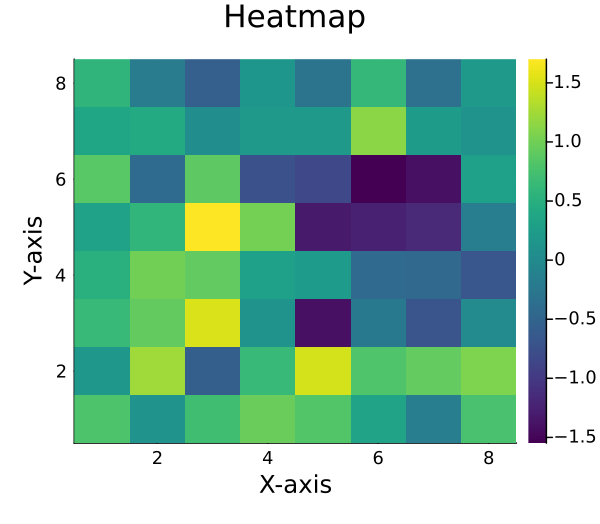

In [5]:
build_heatmap_example(prior, config)

## VI. The problem: noisy weights (before training)

Before any learning, what does the estimator look like? With no transport, the $\varepsilon$-coefficient of the bare weight is, up to a sign convention that is irrelevant in the symmetric phase, the source operator $\mathcal O_0=\sum_{\vec x}\phi(0,\vec x)$. Its distribution over the ensemble is what sets the variance of the correlator estimator: the broader, the noisier.

We promote the first `N_corr = 1000` configurations to `Series` objects, $\phi\to\phi+0\cdot\varepsilon$, and let the formal series carry the $\varepsilon$-derivative through the exponential.

In [6]:
ϵ = Series{Float64,2}((0.0,1.0))
N_corr = 1000

PHI =  Array{Series{Float64,2},4}(undef, config.L1, config.L2 ,1, N_corr)
for n in 1:N_corr
    for i in 1:config.L1
        for j in 1:config.L2
            PHI[i,j,1,n] = Series{Float64,2}((pics[i,j,1,n], 0.0))
        end
    end
end

# (sanity check) the histograms below use the first N_corr configurations of the ensemble
@assert N_corr <= size(pics, 4)

The source operator is the sum over the time slice at index `1` (i.e. $t=0$). `WT_pre` is the bare weight $\exp(-\varepsilon\,\mathcal O_0)$ as a series in $\varepsilon$ (the sign convention is immaterial in the symmetric phase, where $\mathcal O_0$ is distributed symmetrically about zero), and `[2]` reads off its coefficient of $\varepsilon$.

In [7]:
source_term = sum(PHI[1,:,1,:], dims=1)[1,:]
WT_pre = exp.( - ϵ .* source_term )

WTs_pre = []

for n in 1:N_corr
    push!(WTs_pre, (WT_pre[n])[2])
end

**Pre-training distribution of the weights.** This broad histogram is the noise we want to remove.

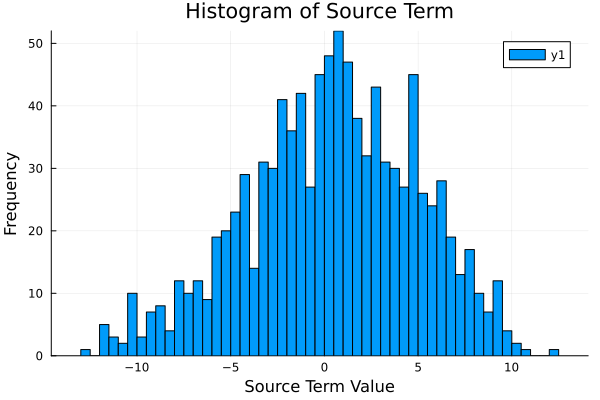

In [8]:
histogram(WTs_pre , bins=50, title="Histogram of Source Term", xlabel="Source Term Value", ylabel="Frequency")

## VII. The transport network and the optimiser

`make_model` (from `src/LamPhi4_trw.jl`) builds the neural transport field $f_\theta:\mathbb R^{8\times8}\to\mathbb R^{8\times8}$ on the periodic lattice `space`. `KLloss_batch` is the leading-order KL loss of Section I. The optimiser is Adam wrapped in an `OptimiserChain` together with (here vanishing) weight decay.

In [9]:
activ = activation_fn(config.activation)
model = make_model(
    space, 
    params_phi4; 
    nodes=config.nodes, 
    activation=activ)

loss_function = KLloss_batch

optimiser = OptimiserChain(WeightDecay(config.weight_decay), Flux.Adam(config.lrate))
opt = Flux.setup(optimiser, model)

(layers = ((conv_branch = (layers = ((conv = (σ = (), weight = Leaf(OptimiserChain(WeightDecay(lambda=0.0), Adam(eta=0.001, beta=(0.9, 0.999), epsilon=1.0e-8)), (nothing, ([0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0], (0.9, 0.999)))), bias = (), stride = ((), ()), pad = ((), (), (), ()), dilation = ((), ()), groups = ()),), (conv = (σ = (), weight = Leaf(OptimiserChain(WeightDecay(lambda=0.0), Adam(eta=0.001, beta=(0.9, 0.999), epsilon=1.0e-8)), (nothing, ([0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;;], [0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;; 

## VIII. Training

Each epoch performs one pass of stochastic gradient descent over the training set (`train_epoch!`, with `K` Hutchinson probes for $\mathrm{tr}\,J_f^2$). For monitoring:

- every second epoch the loss is evaluated on the training and on the **held-out** test set (`evaluate_losses`) — a large gap between the two would signal overfitting;
- every tenth epoch (epochs 9, 19, ...) `evaluate_reweighting_checkpoint` computes the effective sample size (`rw.ess`) and the improved correlator (`rw.corr`) on the held-out configurations.

In [ ]:
fval = zeros(Float64, config.epochs)
ftest = zeros(Float64, config.epochs)
wESS  = zeros(Float64, config.epochs)
correlators_trw = Vector{Vector{ADerrors.uwreal}}(undef, config.epochs)

for epoch in 1:config.epochs
    train_epoch!(model, opt, prior, config.batchsize, var_z, params_phi4;
                 loss_function=loss_function, K=1, rng=rng)

    if epoch % 2 == 1
        train_loss, test_loss = evaluate_losses(model, prior, prior_test, config.test_batchsize,
                                                var_z, params_phi4;
                                                loss_function=loss_function, K=1,
                                                rng=rng)
        fval[epoch] = train_loss
        ftest[epoch] = test_loss

        println("Epoch $epoch | Train Loss: $(fval[epoch])")
        println("Epoch $epoch | Test Loss:  $(ftest[epoch])")
    end

    if epoch % 10== 9
        rw = evaluate_reweighting_checkpoint(model, prior_test, params_phi4;
                                             N=config.N_eval, tag=string(epoch), trace_samples=1,
                                             rng=rng)
        wESS[epoch] = rw.ess
        correlators_trw[epoch] = rw.corr
        println("Epoch $epoch | Test ESS: $(rw.ess)")
    end
end

**Training curves.** Loss on the training and test set, and the held-out ESS at the checkpoints. (Pure post-processing of the arrays filled in the loop above.)

In [ ]:
ep_loss = 1:2:config.epochs      # epochs at which the loss was logged   (epoch % 2 == 1)
ep_ess  = 9:10:config.epochs     # epochs at which the ESS was logged    (epoch % 10 == 9)

p_loss = plot(ep_loss, fval[ep_loss], label="train", xlabel="epoch", ylabel="loss", title="KL loss")
plot!(p_loss, ep_loss, ftest[ep_loss], label="test")

if isempty(ep_ess)
    plot(p_loss, size=(450, 320))
else
    p_ess = plot(ep_ess, wESS[ep_ess], marker=:circle, legend=false,
                 xlabel="epoch", ylabel="ESS (held-out)", title="Effective sample size")
    plot(p_loss, p_ess, layout=(1, 2), size=(900, 320))
end

## IX. Results: the weight distribution after training

First the learned transport field: `f = model(pics)` evaluates $f_\theta$ on the whole ensemble, and the same heat-map routine is applied to it.

In [ ]:
f = model(pics)
build_heatmap_example(f, config)

Now the transported ensemble. For every configuration we build the series $\tilde\phi=\phi+\varepsilon f_\theta(\phi)$ (`PHIT`) and evaluate the three ingredients of the transported weight $\tilde\omega_\varepsilon$ from Section I:

- `action_term` $=S[\phi]-S[T_\varepsilon\phi]$,
- `source_term` $=\mathcal O_0(T_\varepsilon\phi)$,
- `trace_term` $=\mathrm{tr}\,J_{f_\theta}(\phi)$, estimated with a single Hutchinson probe (`ns=1`).

In [ ]:
PHIT =  Array{Series{Float64,2},4}(undef, config.L1, config.L2 ,1, N_corr)
for n in 1:N_corr
    for i in 1:config.L1
        for j in 1:config.L2
            PHIT[i,j,1,n] = Series{Float64,2}((pics[i,j,1,n], f[i,j,1,n]))
        end
    end
end
#PHIT_T = sum(PHIT, dims=2)[:,1,:]

In [ ]:
action_term = (action(PHI,params_phi4) .- action(PHIT,params_phi4))[1,1,1,:]
source_term = sum(PHIT[1,:,1,:], dims=1)[1,:]
trace_term = trJ(model, pics[:,:,:,1:N_corr]; ns=1)[:,1]
WT_post = exp.(action_term .+  ϵ .* source_term + ϵ .* trace_term)




WTs_post = []

for n in 1:N_corr
    push!(WTs_post, (WT_post[n])[2])
end

**Before vs. after.** Overlay of the two distributions of $\omega^{(1)}$: the bare weights (pre-training) and the transported weights (post-training). Because the post-training distribution is much narrower, it is also shown on its own below.

In [ ]:
histogram(WTs_post , bins=50, title="Histogram of Source Term", xlabel="Source Term Value", ylabel="Frequency", alpha=0.5, label="Post-Training")
histogram!(WTs_pre, bins=50,  alpha=0.5, label="Pre-Training")

In [ ]:
# the post-training distribution on its own (zoom)
histogram(WTs_post, bins=50, title="Histogram of Source Term (post-training only)",
          xlabel="Source Term Value", ylabel="Frequency", label="Post-Training", color=2)

**Quantifying the collapse.** The width of the distribution of $\omega^{(1)}$ is the noise of the estimator. Below we compare the variances and the leading-order ESS $=1/(1+\mathrm{Var}[\omega^{(1)}])$ before and after training. For the correlator at large separation, the variance-reduction factor is approximately $\mathrm{Var}[\mathcal O_0]/\langle\rho^2\rangle$ (proceedings, Eq. 16), so the ratio printed here is a direct estimate of the attainable gain.

Note that the trace term uses a single Hutchinson probe: this adds independent noise to $\omega^{(1)}$, so the post-training width shown here is an *upper bound* on what the trained map achieves with an exact trace.

In [ ]:
var_pre  = Statistics.var(Float64.(WTs_pre))
var_post = Statistics.var(Float64.(WTs_post))

ess_pre  = 1 / (1 + var_pre)
ess_post = 1 / (1 + var_post)

println("Var[ω¹]  pre-training : ", var_pre)
println("Var[ω¹]  post-training: ", var_post)
println("variance reduction    : ", var_pre / var_post, "×")
println()
println("ESS (leading order)  pre-training : ", ess_pre)
println("ESS (leading order)  post-training: ", ess_post)

## X. Scope, limitations and outlook

**What this notebook is.** A compact, end-to-end illustration of the method: data → transport network → variational training → weight distribution. It runs the training script of the thesis code base at demonstration scale.

**What it is not** (and what the thesis does additionally):
- *Scale.* One parameter point on an $8\times8$ lattice with a short training run. The thesis studies a $32\times8$ lattice, trains for $\mathcal O(10^4)$ epochs, and scans $\kappa$ and $\lambda$.
- *Held-out data.* The histograms above use the first `N_corr` configurations of the *full* ensemble, i.e. a mixture of training and test configurations. The held-out test loss and test ESS (training curves) are the checks against overfitting; the thesis measures physics on a statistically independent ensemble.
- *Trace estimator.* The trace in the weights uses a single Hutchinson probe. The thesis shows this stochastic trace is the main bottleneck of the method (residual variance saturates once the trace is accurate, while the quality of the trained map is limited by trace noise in the loss).
- *No correlator here.* The notebook stops at the weights. The thesis builds the improved correlator $C(t)$ and effective mass from them, with autocorrelation-aware error analysis (Γ-method, `ADerrors`) and validation against the exact free-theory solution.

**What the full study finds** (thesis, Chapter *Results*; proceedings):
- Free theory: variance of the correlator reduced by **6–8 orders of magnitude**, with the largest gains closest to criticality.
- Interacting theory: gains depend mainly on the quartic coupling — variance ratio $\approx10^{-2}$ at $\lambda=0.005$, $\approx3\times10^{-1}$ at $\lambda=0.05$, and just below break-even at $\lambda=0.5$.

**Beyond lattice field theory.** The technique — learning a variational transformation of a sampling distribution to control the variance of an estimator, with an unbiasedness guarantee that holds for any network — is not specific to $\phi^4$. It applies wherever Monte Carlo sampling from an intractable high-dimensional distribution is the bottleneck; moving to a new problem amounts to redefining the target distribution and the objective.

**References**
- L. Spatscheck, Master's thesis, University of Southern Denmark (2026), Chapters *Numerical Implementation* and *Results*.
- P. Butti, G. Catumba, A. Nada, L. Spatscheck, *A variational framework for variance reduction in lattice field theory*, LATTICE 2026 proceedings.
- M. S. Albergo et al., *Introduction to Normalizing Flows for Lattice Field Theory*, arXiv:2101.08176 — background on flow-based methods in lattice field theory (and the model for this notebook's format).

## Appendix: plain periodic CNN (defined in the original script, not used above)

The original script also defines a simple periodic convolutional network `make_CNN`. It is not used in the training run above (`make_model` is); it is kept here unchanged for completeness.

In [ ]:
function make_CNN(space::Grid, params::Phi4Params{T}; nodes=16, activation=tanh) where T

    vol = space.iL
    Nₜ = vol[1]
    Nₓ = prod(vol[2:end])

    conv_branch = Chain(
        PeriodicConv((3, 3), 1 => nodes; σ=activation, bias=false),
        PeriodicConv((3, 3), nodes => nodes; σ=activation, bias=false),
        PeriodicConv((3, 3), nodes => 1; σ=identity),
    ) |> Flux.f64

    return Chain(x -> conv_branch(x),
                x -> exp.(x))
end